<a href="https://colab.research.google.com/github/roohiverma-05/CMB-Analysis/blob/main/CMB_Foreground_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 31.3 MB/s eta 0:00:00


In [3]:
!wget -O map_dust.fits.gz "http://lambda.gsfc.nasa.gov/data/footprint-maps/Planck_Dust_256.fits.gz"

!wget -O map_synch.fits.gz "http://lambda.gsfc.nasa.gov/data/footprint-maps/Planck_Synch_256.fits.gz"

!wget -O map_143.fits "http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=HFI_SkyMap_143_2048_R3.01_full.fits"


--2026-03-18 15:49:17--  http://lambda.gsfc.nasa.gov/data/footprint-maps/Planck_Dust_256.fits.gz
Resolving lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)... 129.164.179.68, 2001:4d0:2310:150::68
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://lambda.gsfc.nasa.gov/data/footprint-maps/Planck_Dust_256.fits.gz [following]
--2026-03-18 15:49:18--  https://lambda.gsfc.nasa.gov/data/footprint-maps/Planck_Dust_256.fits.gz
Connecting to lambda.gsfc.nasa.gov (lambda.gsfc.nasa.gov)|129.164.179.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2774295 (2.6M) [application/x-gzip]
Saving to: ‘map_dust.fits.gz’

map_dust.fits.gz    100%[===================>]   2.65M  2.71MB/s    in 1.0s    

2026-03-18 15:49:19 (2.71 MB/s) - ‘map_dust.fits.gz’ saved [2774295/2774295]

URL transformed to HTTPS due to an HSTS policy
--2026-03-18 15:49:19--  https://lambda.gs

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import scipy.optimize as minimize

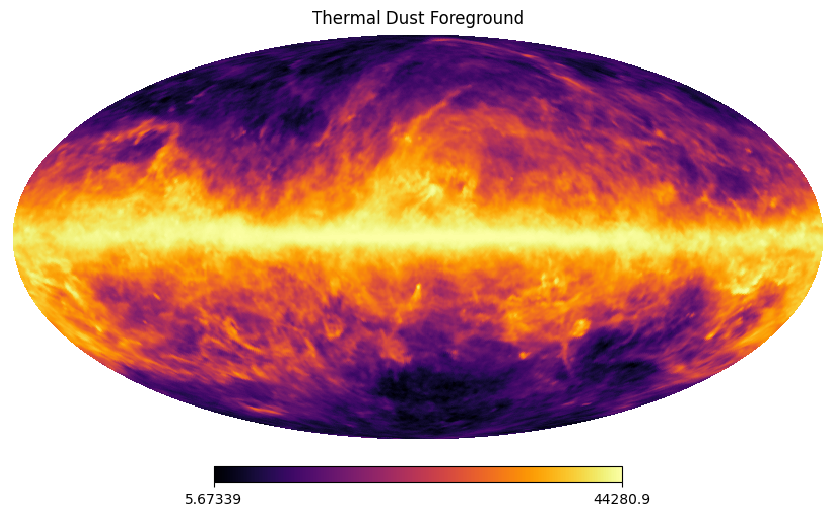

In [5]:
dust_map = hp.read_map("map_dust.fits.gz")

hp.mollview(dust_map, title = "Thermal Dust Foreground", cmap = "inferno", norm = "hist")
plt.show()

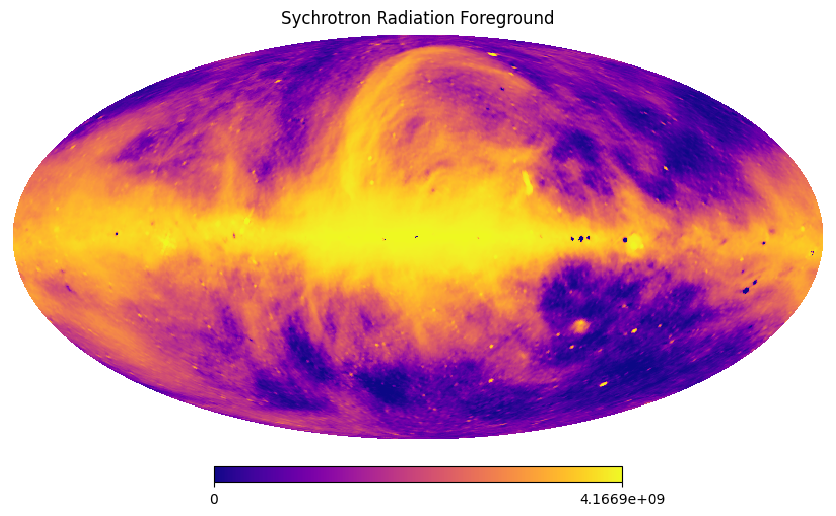

In [6]:
synchrn_map = hp.read_map("map_synch.fits.gz")

hp.mollview(synchrn_map, title = "Sychrotron Radiation Foreground", cmap="plasma", norm="hist")
plt.show()

Downgrading the sky map (143GHz) with a nside of 2048 to 256 to match with the synchrotron and dust-dust emissions.

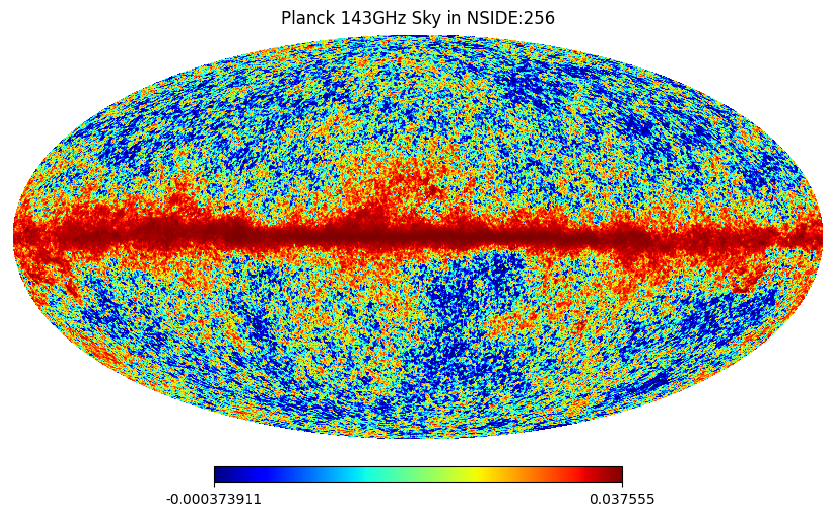

In [7]:
map_143_high_res = hp.read_map("map_143.fits")

#Downgrading the pixel resolution from nside = 2048 to 256
map_143_downgrade = hp.ud_grade(map_143_high_res, nside_out=256)

# Plot the map
hp.mollview(map_143_downgrade, title = "Planck 143GHz Sky in NSIDE:256", cmap="jet", norm = "hist")
plt.show()

Removal of Foreground by Internal Linear Combination

Best possible value of alpha: 436.4008
Best possible value of beta: -35.0242


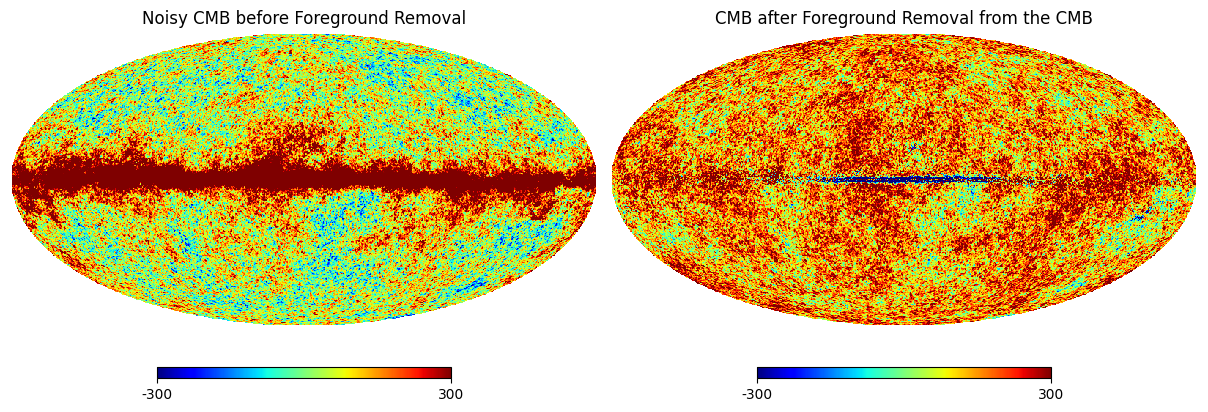

In [8]:
from scipy.optimize import minimize

#Unit conversion of Kelvin to microkelvins:
target_map = map_143_downgrade*1e6
# Standardazition of the maps:
dust_map_standard = (dust_map-np.mean(dust_map))/np.std(dust_map)
synchrn_map_standard = (synchrn_map - np.mean(synchrn_map))/np.std(synchrn_map)

def calculate_variance(weights):
  alpha, beta = weights
  #Subtract the foregrounds using the guess for weights:
  cleaned_test = target_map - (alpha * dust_map_standard) - (beta * synchrn_map_standard)
  return np.var(cleaned_test)

# Weights calculations:
initial_guess =  [1.0,1.0]
result = minimize(calculate_variance, initial_guess)

best_alpha, best_beta = result.x
print(f"Best possible value of alpha: {best_alpha:.4f}")
print(f"Best possible value of beta: {best_beta:.4f}")

cleaned_map = target_map - (best_alpha*dust_map_standard) - (best_beta*synchrn_map_standard)

plt.figure(figsize=(12,8))
hp.mollview(target_map, title ="Noisy CMB before Foreground Removal", sub = (1,2,1), cmap = "jet", min=-300, max=300)
hp.mollview(cleaned_map, title = "CMB after Foreground Removal from the CMB", sub = (1,2,2), cmap = "jet", min=-300, max=300)
plt.show()

Monopole to be removed in order to get the temperature oscillations centered on zero.


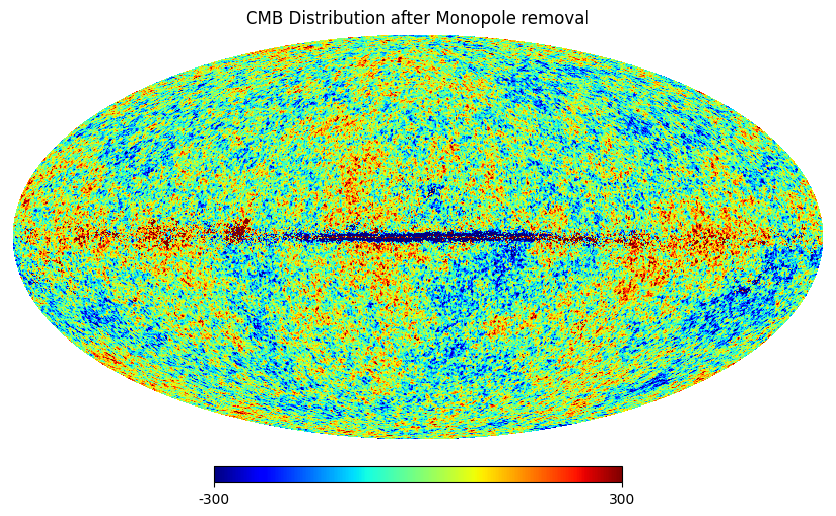

In [9]:
cleaned_map = hp.remove_monopole(cleaned_map)
hp.mollview(cleaned_map, title = "CMB Distribution after Monopole removal", cmap="jet", min = -300, max = 300)
plt.show()

Using Galctic Masking to literally cut out the central piece of dust emission.

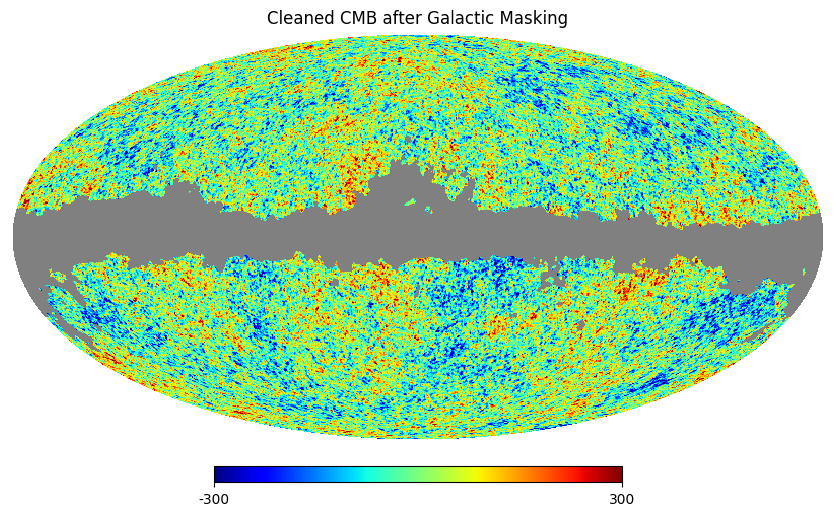

In [28]:
galaxy_percentile = np.percentile(dust_map, 80)
masked_cmb_map = np.copy(cleaned_map)

masked_cmb_map[dust_map > galaxy_percentile] = hp.UNSEEN

hp.mollview(masked_cmb_map, title="Cleaned CMB after Galactic Masking", cmap = "jet", min = -300, max = +300)

Our next goal is to create a power spectrum of this data that is masked and according to the ideal powerspectrum mapping we will adjust our data


The fraction of the sky f_sky is:0.800


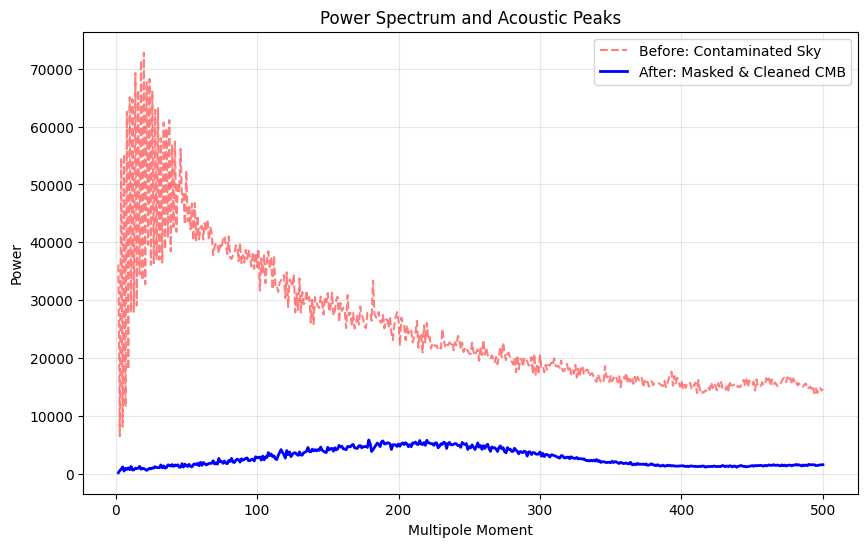

In [29]:
good_pixels = (masked_cmb_map != hp.UNSEEN)
f_sky = np.sum(good_pixels)/ len(masked_cmb_map)
print(f"The fraction of the sky f_sky is:{f_sky:.3f}")

# Power spectra calculations upto multipole l_max = 500
cl_cleaned_masked = hp.anafast(masked_cmb_map, lmax = 500)

cl_cleaned_corrected = cl_cleaned_masked / f_sky
ell = np.arange(len(cl_cleaned_corrected))
dl_cleaned = ell * (ell + 1) * cl_cleaned_corrected / (2 * np.pi)

cl_dirty = hp.anafast(target_map, lmax=500)
dl_dirty = ell * (ell + 1) * cl_dirty / (2 * np.pi)

# 5. Plot the Final Results!
plt.figure(figsize=(10, 6))

plt.plot(ell[2:], dl_dirty[2:], label="Before: Contaminated Sky", color='red', alpha=0.5, linestyle='--')
plt.plot(ell[2:], dl_cleaned[2:], label="After: Masked & Cleaned CMB", color='blue', linewidth=2)

plt.title("Power Spectrum and Acoustic Peaks")
plt.xlabel("Multipole Moment")
plt.ylabel("Power")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Let us now compare our data with that of the standard model of cosmology which is the Lambda CDM model. We can compare this with that of the Planck data COM_PowerSpect_CMB-TT-full_R3.01.txt file.

/tmp/ipykernel_391/2797100528.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  theoretical_data = pd.read_csv(esa_url, delim_whitespace = True, comment='#', header = None, names = ['L', 'TT', 'TE', 'EE', 'BB', 'PP'])


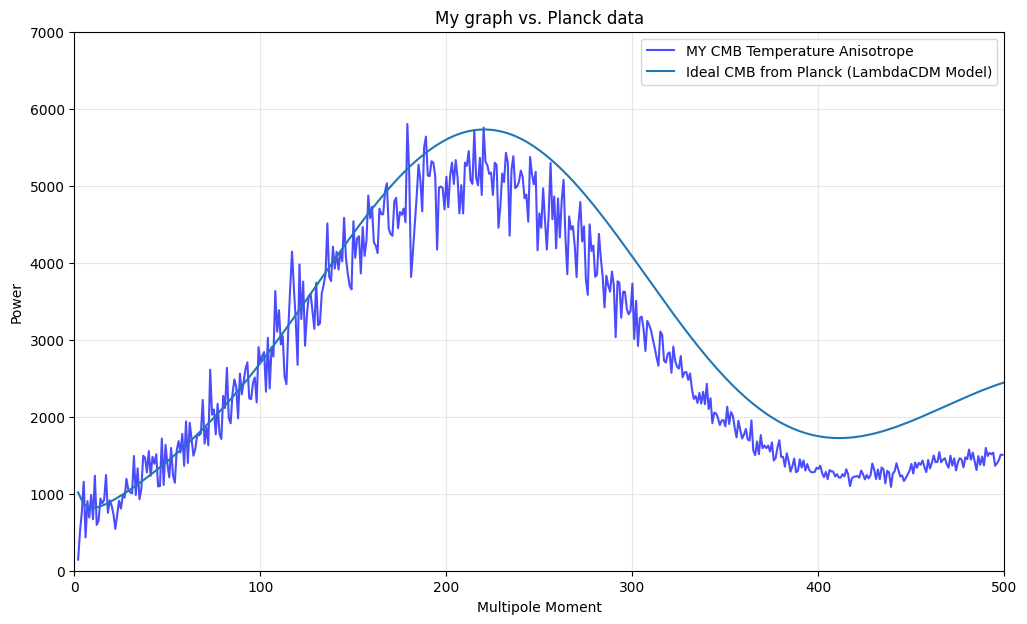

In [32]:
import pandas as pd
import os
import urllib.request

esa_url = "https://pla.esac.esa.int/pla/aio/product-action?COSMOLOGY.FILE_ID=COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"

theory_file =  "planck_theory.txt"

if not os.path.exists(theory_file):
  import urllib.request
  urllib.request.urlretrieve(esa_url, theory_file)

theoretical_data = pd.read_csv(esa_url, delim_whitespace = True, comment='#', header = None, names = ['L', 'TT', 'TE', 'EE', 'BB', 'PP'])

l_theory = pd.to_numeric(theoretical_data['L'], errors='coerce')
dl_theory = pd.to_numeric(theoretical_data['TT'], errors='coerce')

plt.figure(figsize=(12,7))

#My result
plt.plot(ell[2:500], dl_cleaned[2:500], label= "MY CMB Temperature Anisotrope", color = 'blue', alpha = 0.7)

#Result from the Lambda CDM model
plt.plot(l_theory[:500], dl_theory[:500], label = "Ideal CMB from Planck (LambdaCDM Model)")

plt.title("My graph vs. Planck data")
plt.xlabel("Multipole Moment")
plt.ylabel("Power")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 7000)
plt.grid(True, alpha=0.3)
plt.show()
